<a href="https://colab.research.google.com/github/dimasprygaa/ATS-CV/blob/main/ATS_VISION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tqdm import tqdm

In [ ]:
print("Loading dataset...")

data = pd.read_csv("emnist-balanced-train.csv")

print("Dataset loaded!")

Loading dataset...
Dataset loaded!


In [ ]:
# Kolom pertama = label
y = data.iloc[:, 0].values

# Sisanya = pixel image
X = data.iloc[:, 1:].values

print("Original Dataset Shape:", X.shape)

Original Dataset Shape: (112799, 784)


In [ ]:
X = X[:300]
y = y[:300]

print("Subset Shape:", X.shape)

Subset Shape: (300, 784)


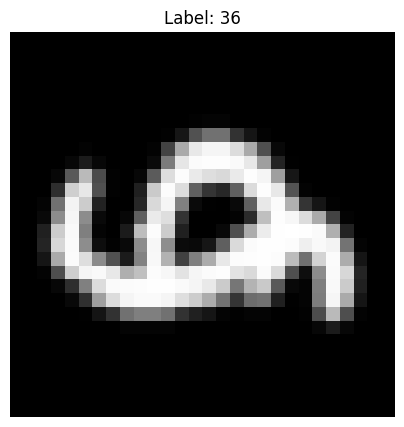

In [ ]:
plt.figure(figsize=(5,5))

img = X[0].reshape((28,28))

plt.imshow(img, cmap='gray')

plt.title(f"Label: {y[0]}")

plt.axis('off')

plt.show()

In [ ]:
print("Extracting HOG features...")

hog_features = []

for image in tqdm(X):

    img = image.reshape((28, 28))

    features = hog(
        img,

        # jumlah arah gradien
        orientations=9,

        # ukuran pixel per cell
        pixels_per_cell=(4,4),

        # jumlah cell per block
        cells_per_block=(2,2),

        # normalisasi
        block_norm='L2-Hys'
    )

    hog_features.append(features)

hog_features = np.array(hog_features)

print("HOG Feature Shape:", hog_features.shape)

Extracting HOG features...


100%|██████████| 300/300 [00:00<00:00, 1040.81it/s]

HOG Feature Shape: (300, 1296)


In [ ]:
svm_model = SVC(

    # kernel terbaik untuk image classification
    kernel='rbf',

    # regularization
    C=10,

    # gamma otomatis
    gamma='scale'
)

In [ ]:
loo = LeaveOneOut()

y_true = []
y_pred = []

print("Running LOOCV...")

for train_index, test_index in tqdm(
    loo.split(hog_features),
    total=len(hog_features)
):

    # training data
    X_train = hog_features[train_index]
    y_train = y[train_index]

    # testing data
    X_test = hog_features[test_index]
    y_test = y[test_index]

    # training SVM
    svm_model.fit(X_train, y_train)

    # prediction
    prediction = svm_model.predict(X_test)

    # simpan hasil
    y_true.append(y_test[0])
    y_pred.append(prediction[0])

Running LOOCV...


100%|██████████| 300/300 [00:37<00:00,  8.02it/s]


In [ ]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)
print("\n===================================")
print("HASIL EVALUASI")
print("===================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")

print(classification_report(y_true, y_pred))


HASIL EVALUASI
Accuracy  : 0.4433
Precision : 0.4196
F1 Score  : 0.4092

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.20      0.25      0.22         4
           2       0.00      0.00      0.00         6
           3       0.35      0.80      0.48        10
           4       0.30      0.38      0.33         8
           5       0.33      0.20      0.25         5
           6       0.50      0.67      0.57         6
           7       0.40      0.40      0.40         5
           8       0.44      0.44      0.44         9
           9       0.23      0.38      0.29         8
          10       0.40      0.33      0.36         6
          11       0.00      0.00      0.00         6
          12       0.54      0.88      0.67         8
          13       1.00      0.60      0.75         5
          14       0.75      0.50      0.60         6
          15       0.33      0.43      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

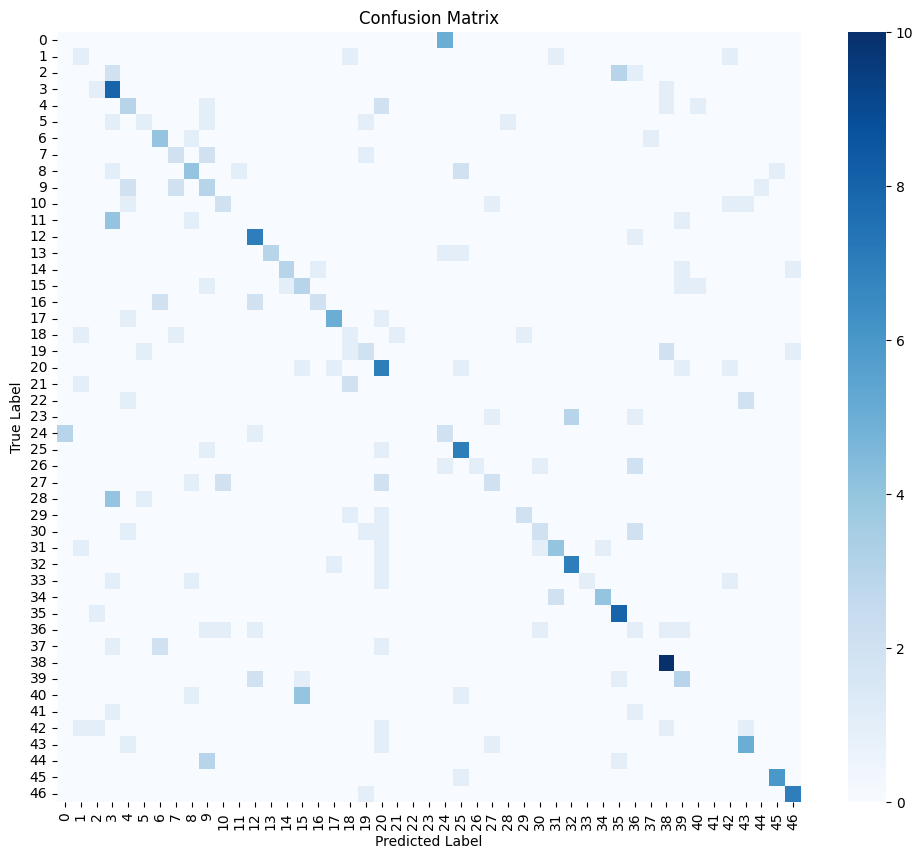

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()